# 5-7 Talib Strategy Builder

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/5-7_talib_strategy_builder.ipynb)

**對應影片**：第 5 章 單元 5-7、5-8【Talib Strategies】研發策略只要一行！Talib Strategy Builder 1、2

**和影片的差異**

- 資料改從 Binance 公開資料端點下載（`data-api.binance.vision`，不需金鑰、Colab 可用），`get_all_binance` 的寫法和影片一樣。
- TA-Lib 已經隨 `finlab_crypto` 一起安裝（官方 wheel），不需要再 `pip install talib-binary`。
- 1 小時 K 線從影片錄製時的約 2.8 萬根，成長到現在超過 8 萬根。為了讓 Colab 免費版幾分鐘內跑完最佳化，預設只用 `START` 之後的資料（和影片的資料量相近）；想用完整歷史，把 `START` 改成 `None`。
- `backtest` 的 `variables` 可以直接給 `{}`（影片中是 `None`），兩者效果相同。
- 最後的「最終策略」影片用 2019 年以後的資料；這裡直接用 `START` 之後的資料。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
# 最佳化使用的資料起點；改成 None 使用全部歷史（需要較多記憶體與時間）
START = '2023-01-01'

In [4]:
import finlab_crypto

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '1h').loc[START:]

BTCUSDT 1h: 79678 candles (2017-08-17 ~ 2026-09-24 09:00 UTC)


# MACD 策略

## 查看 TA-Lib 函式的用法

In [5]:
import talib

help(talib.MACD)

Help on function MACD in module talib._ta_lib:

MACD(real, fastperiod=-2147483648, slowperiod=-2147483648, signalperiod=-2147483648)
    MACD(ndarray real, int fastperiod=-0x80000000, int slowperiod=-0x80000000, int signalperiod=-0x80000000)

    MACD(real[, fastperiod=?, slowperiod=?, signalperiod=?])

    Moving Average Convergence/Divergence (Momentum Indicators)

    Inputs:
        real: (any ndarray)
    Parameters:
        fastperiod: 12
        slowperiod: 26
        signalperiod: 9
    Outputs:
        macd
        macdsignal
        macdhist



## 使用 TA-Lib 函式

`talib.MACD` 回傳三條線，`[2]` 取第三條 macdhist（柱狀體）。

<Axes: >

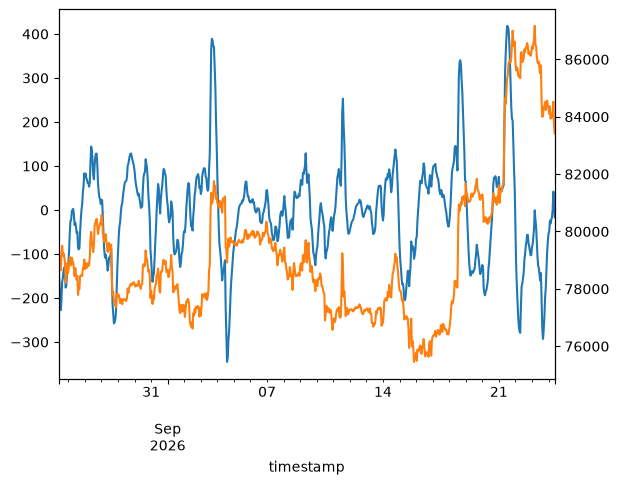

In [6]:
macdhist = talib.MACD(ohlcv.close, fastperiod=12, slowperiod=26, signalperiod=9)[2]

LAST_MONTH_BARS = 24 * 30  # 1 小時 K 線，30 天
macdhist.iloc[-LAST_MONTH_BARS:].plot()
ohlcv.close.iloc[-LAST_MONTH_BARS:].plot(secondary_y=True)

In [7]:
# 所有 TA-Lib 指標
len(talib.get_functions()), talib.get_functions()[:10]

(201,
 ['HT_DCPERIOD',
  'HT_DCPHASE',
  'HT_PHASOR',
  'HT_SINE',
  'HT_TRENDMODE',
  'ADD',
  'CUMSUM',
  'DIV',
  'MAX',
  'MAXINDEX'])

## 黃金交叉、死亡交叉函式

[isinstance](https://www.w3schools.com/python/ref_func_isinstance.asp) 判斷 s2 是數字還是序列。

In [8]:
import numbers


def crossover(s1, s2):
    """s1 由下往上穿過 s2（s2 可以是數字或另一條序列）"""
    previous = s2 if isinstance(s2, numbers.Number) else s2.shift()
    return (s1 > s2) & (s1.shift() < previous)


def crossunder(s1, s2):
    """s1 由上往下穿過 s2"""
    previous = s2 if isinstance(s2, numbers.Number) else s2.shift()
    return (s1 < s2) & (s1.shift() > previous)

In [9]:
from finlab_crypto import Strategy


@Strategy(fastperiod=12, slowperiod=26, signalperiod=9)
def macd_strategy(ohlcv):
    macdhist = talib.MACD(
        ohlcv.close,
        fastperiod=macd_strategy.fastperiod,
        slowperiod=macd_strategy.slowperiod,
        signalperiod=macd_strategy.signalperiod)[2]

    entries = crossover(macdhist, 0)
    exits = crossunder(macdhist, 0)
    figures = {'figures': {'macdhist': macdhist}}
    return entries, exits, figures


macd_strategy.backtest(ohlcv, variables={}, freq='1h', plot=True)

# 5-8 Talib Strategy Builder：一行建立策略

`TalibStrategy(指標名稱, 進場條件, 出場條件)`：

- 條件用 [lambda](https://www.w3schools.com/python/python_lambda.asp) 表示，輸入 `(ohlcv, 指標)`，輸出 True / False 序列
- 指標有多條線時用名稱取出，例如 `macd.macdhist`
- 指標本身的參數（`fastperiod` 等）自動變成策略參數，可以最佳化

In [10]:
help(talib.RSI)

Help on function RSI in module talib._ta_lib:

RSI(real, timeperiod=-2147483648)
    RSI(ndarray real, int timeperiod=-0x80000000)

    RSI(real[, timeperiod=?])

    Relative Strength Index (Momentum Indicators)

    Inputs:
        real: (any ndarray)
    Parameters:
        timeperiod: 14
    Outputs:
        real



In [11]:
from finlab_crypto.talib_strategy import TalibStrategy

macd_strategy = TalibStrategy(
    'MACD',
    lambda ohlcv, macd: crossover(macd.macdhist, 0),
    lambda ohlcv, macd: crossunder(macd.macdhist, 0),
)

macd_strategy.backtest(ohlcv, variables={}, freq='1h', plot=True)

## 練習：布林通道突破策略

收盤價突破上軌買進、跌破下軌賣出。

In [12]:
help(talib.BBANDS)

Help on function BBANDS in module talib._ta_lib:

BBANDS(real, timeperiod=-2147483648, nbdevup=-4e+37, nbdevdn=-4e+37, matype=0)
    BBANDS(ndarray real, int timeperiod=-0x80000000, double nbdevup=-4e37, double nbdevdn=-4e37, int matype=0)

    BBANDS(real[, timeperiod=?, nbdevup=?, nbdevdn=?, matype=?])

    Bollinger Bands (Overlap Studies)

    Inputs:
        real: (any ndarray)
    Parameters:
        timeperiod: 20
        nbdevup: 2.0
        nbdevdn: 2.0
        matype: 0 (Simple Moving Average)
    Outputs:
        upperband
        middleband
        lowerband



In [13]:
bbands_strategy = TalibStrategy(
    'BBANDS',
    lambda ohlcv, bb: crossover(ohlcv.close, bb.upperband),
    lambda ohlcv, bb: crossunder(ohlcv.close, bb.lowerband),
)

bbands_strategy.backtest(ohlcv, variables={'timeperiod': 50}, freq='1h', plot=True)

## Talib Filter：一行建立濾網

線性迴歸角度 > 0（趨勢向上）才允許進場。

Help on function LINEARREG_ANGLE in module talib._ta_lib:

LINEARREG_ANGLE(real, timeperiod=-2147483648)
    LINEARREG_ANGLE(ndarray real, int timeperiod=-0x80000000)

    LINEARREG_ANGLE(real[, timeperiod=?])

    Linear Regression Angle (Statistic Functions)

    Inputs:
        real: (any ndarray)
    Parameters:
        timeperiod: 14
    Outputs:
        real



<Axes: xlabel='timestamp'>

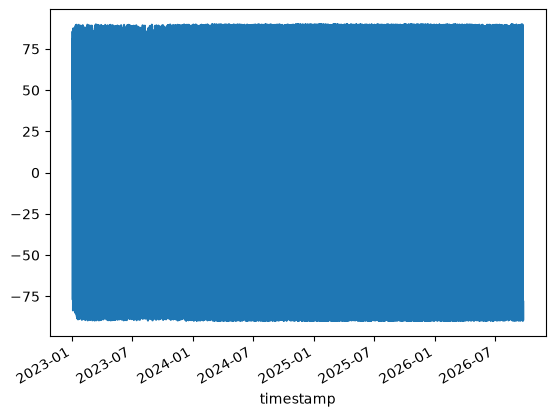

In [14]:
help(talib.LINEARREG_ANGLE)

talib.LINEARREG_ANGLE(ohlcv.close, timeperiod=14).plot()

In [15]:
from finlab_crypto.talib_filter import TalibFilter

line_angle_filter = TalibFilter(
    'LINEARREG_ANGLE',
    lambda ohlcv, angle: angle > 0,
)
f14 = line_angle_filter.create({'timeperiod': 14})

## 策略 + 濾網一起最佳化

這格要回測 20 × 20 × 8 = 3200 組參數：本機測試約 6 分鐘，Colab 免費版會更久。
趕時間可以先把上方的 `QUICK_RUN` 改成 `True` 快速看一遍，之後再改回 `False` 看完整結果。

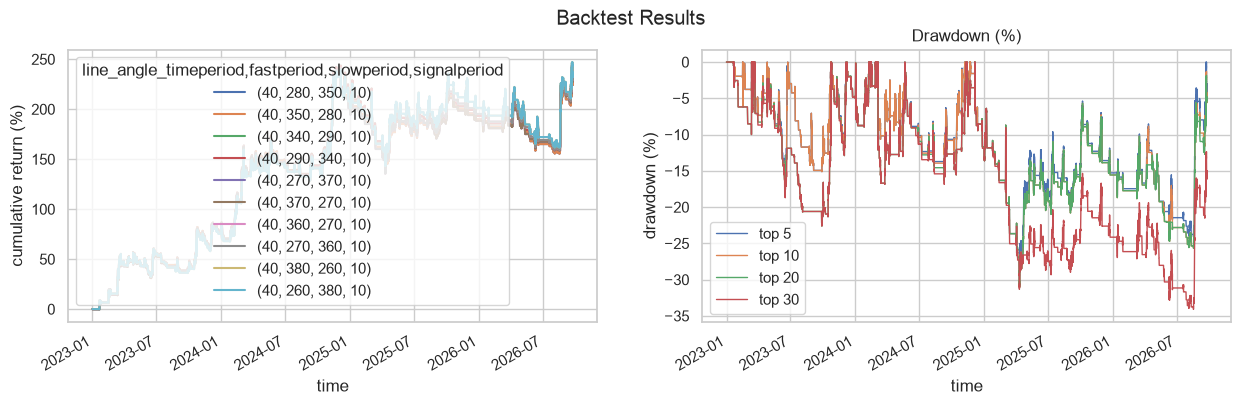

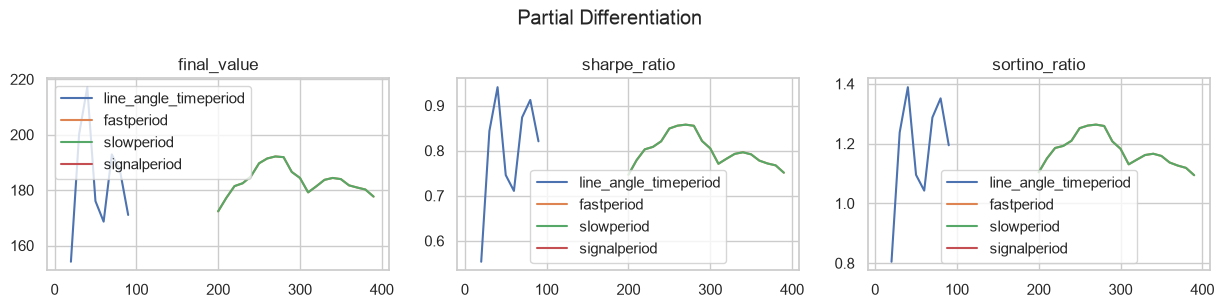

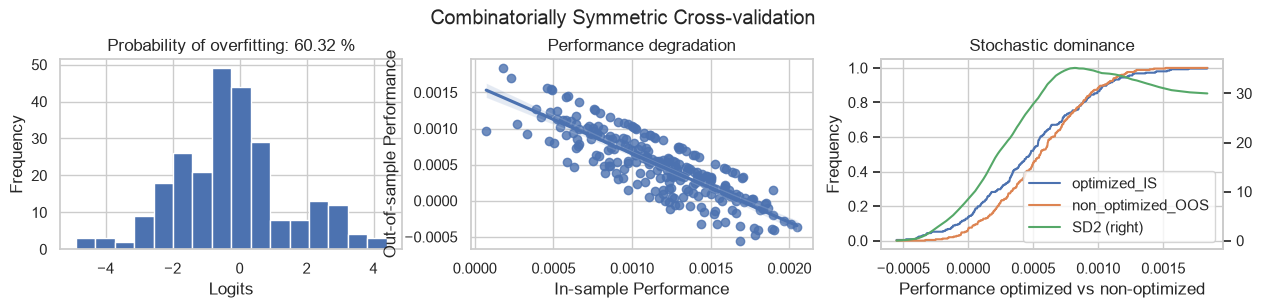

In [16]:
import numpy as np

macd_step = 50 if QUICK_RUN else 10
angle_step = 40 if QUICK_RUN else 10
macd_vars = {
    'fastperiod': np.arange(200, 400, macd_step),
    'slowperiod': np.arange(200, 400, macd_step),
    'signalperiod': 10,
}
angle_vars = {'timeperiod': np.arange(20, 100, angle_step)}

portfolio = macd_strategy.backtest(ohlcv, variables=macd_vars,
                                   filters={'line_angle': line_angle_filter.create(angle_vars)},
                                   freq='1h', plot=True)

## 最終策略

In [17]:
macd_vars = {
    'fastperiod': 320,
    'slowperiod': 300,
    'signalperiod': 10,
}
line_angle_filter_vars = {'timeperiod': 20}

portfolio = macd_strategy.backtest(
    ohlcv,
    variables=macd_vars,
    filters={'line_angle': line_angle_filter.create(line_angle_filter_vars)},
    freq='1h', plot=True)